# Time Offset Sync
Cross-correlate a test instrument's CH4 against a reference instrument to find per-file time offsets.

**Workflow:**
1. Run imports
2. Fill in the Config cell — paths, column names, output location
3. Load reference instrument data
4. Auto cross-correlate all test instrument files
5. Step through files visually with slider + buttons
6. Save confirmed offsets and rejected list to JSON

In [9]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.widgets as mwidgets
from pathlib import Path

%matplotlib widget

## Config

In [10]:
# ── Reference instrument (ground truth — all others are aligned to this) ───────
REF_DIR     = Path('../temp/data/raw/picarro_raw/cleaned')   # folder containing *_clean.csv files
REF_COL     = 'CH4'                         # column to cross-correlate on
REF_RAW_EXT = '.csv'                                 # Picarro raw file extension

# ── Test instrument (the one being synced) ─────────────────────────────────────
TEST_DIR     = Path('../temp/data/raw/aeris460_raw/cleaned')  # folder containing *_clean.csv files
TEST_COL     = 'CH4'                            # column to cross-correlate on
TEST_NAME    = 'aeris460'                             # label shown in plots
TEST_RAW_EXT = '.csv'                                 # Aeris raw file extension

# ── Output ─────────────────────────────────────────────────────────────────────
# Saves two files: <OUTPUT_STEM>_timeshift.json and <OUTPUT_STEM>_rejected.json
OUTPUT_DIR  = Path('../temp/data/aaron')
OUTPUT_STEM = 'aeris460'   # e.g. 'aeris460' -> aeris460_timeshift.json

# ── Cross-correlation tuning ───────────────────────────────────────────────────
RESAMPLE_S = 1    # resample interval in seconds
MAX_LAG_S  = 120  # maximum lag to search (seconds)

## Helpers

In [11]:
def load_cleaned(path, col):
    df = pd.read_csv(path, index_col='TIMESTAMP', parse_dates=True)
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in {path.name}. Available: {df.columns.tolist()}")
    return df[col].dropna()

def resample_series(s, freq_s):
    s = s.resample(f'{freq_s}s').mean()
    s = s.interpolate(method='time', limit=10)
    return s

def load_all_ref(directory, col):
    files = sorted(directory.glob('*_clean.csv'))
    if not files:
        raise FileNotFoundError(f'No *_clean.csv files found in {directory}')
    print(f'  Loading {len(files)} reference file(s) from {directory.name}...')
    parts = [load_cleaned(f, col) for f in files]
    combined = pd.concat(parts).sort_index()
    combined = combined[~combined.index.duplicated(keep='first')]
    return resample_series(combined, RESAMPLE_S)

def cross_correlate(ref, sig, max_lag_s, freq_s):
    start = max(ref.index[0], sig.index[0])
    end   = min(ref.index[-1], sig.index[-1])
    if start >= end:
        print('  [warn] No overlapping time window.')
        return 0.0
    combined = pd.DataFrame({'r': ref[start:end], 's': sig[start:end]}).dropna()
    if len(combined) < 10:
        print('  [warn] Fewer than 10 overlapping points.')
        return 0.0
    r_arr = (combined['r'] - combined['r'].mean()).values
    s_arr = (combined['s'] - combined['s'].mean()).values
    max_lag_samples = max_lag_s // freq_s
    corr = np.correlate(r_arr, s_arr, mode='full')
    lags = np.arange(-(len(r_arr) - 1), len(r_arr))
    mask = np.abs(lags) <= max_lag_samples
    return float(lags[mask][np.argmax(corr[mask])] * freq_s)

def load_json(path):
    if not path.exists():
        return {}
    with open(path) as f:
        return json.load(f)

def save_json(data, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w') as f:
        json.dump(data, f, indent=2)
    print(f'  Saved -> {path}')

def json_key(cleaned_path):
    """Use the cleaned filename directly as the JSON key."""
    return cleaned_path.name

print('Helpers loaded.')

Helpers loaded.


## Step 1 — Load reference instrument data

In [12]:
ref_data = load_all_ref(REF_DIR, REF_COL)
print(f'Reference ({REF_COL}): {len(ref_data):,} samples')
print(f'  Range: {ref_data.index[0]}  ->  {ref_data.index[-1]}')

  Loading 187 reference file(s) from cleaned...
Reference (CH4): 800,535 samples
  Range: 2026-02-03 16:59:08  ->  2026-02-12 23:21:22


## Step 2 — Auto cross-correlate all test instrument files

In [13]:
test_files = sorted(TEST_DIR.glob('*_clean.csv'))
if not test_files:
    raise FileNotFoundError(f'No *_clean.csv files found in {TEST_DIR}')
print(f'Test instrument : {TEST_NAME}  |  {len(test_files)} files found\n')

suggestions = {}
for f in test_files:
    key = json_key(f)
    test_ch4 = resample_series(load_cleaned(f, TEST_COL), RESAMPLE_S)
    suggestions[key] = cross_correlate(ref_data, test_ch4, MAX_LAG_S, RESAMPLE_S)

print(f'\n{"IDX":>4}  {"FILE":<55}  {"AUTO LAG":>10}')
print('-' * 75)
for i, f in enumerate(test_files):
    key = json_key(f)
    print(f'[{i:>2}]  {f.name:<55}  {suggestions[key]:>+.0f}s')

Test instrument : aeris460  |  44 files found

  [warn] Fewer than 10 overlapping points.
  [warn] Fewer than 10 overlapping points.
  [warn] Fewer than 10 overlapping points.
  [warn] Fewer than 10 overlapping points.
  [warn] Fewer than 10 overlapping points.
  [warn] Fewer than 10 overlapping points.

 IDX  FILE                                                       AUTO LAG
---------------------------------------------------------------------------
[ 0]  Ultra100460_260203_172639_clean.csv                      +6s
[ 1]  Ultra100460_260203_174018_clean.csv                      +2s
[ 2]  Ultra100460_260203_195345_clean.csv                      +0s
[ 3]  Ultra100460_260203_195917_clean.csv                      +4s
[ 4]  Ultra100460_260204_000750_clean.csv                      +0s
[ 5]  Ultra100460_260204_002516_clean.csv                      +0s
[ 6]  Ultra100460_260204_003035_clean.csv                      +0s
[ 7]  Ultra100460_260204_160118_clean.csv                      +6s
[ 8]  Ul

## Step 3 - Visual inspection

- **Lag**: shifts Aeris horizontally (this is what gets saved)
- **V-Scale / V-Offset**: visual only — stretch and shift Aeris vertically to match Picarro peaks
- **Commit & Next**: saves current lag and moves to next file
- **Next**: skips without committing (uses auto-suggested lag)
- Zoom with the toolbar, then use the sliders

`confirmed` dict persists across re-runs of this cell.

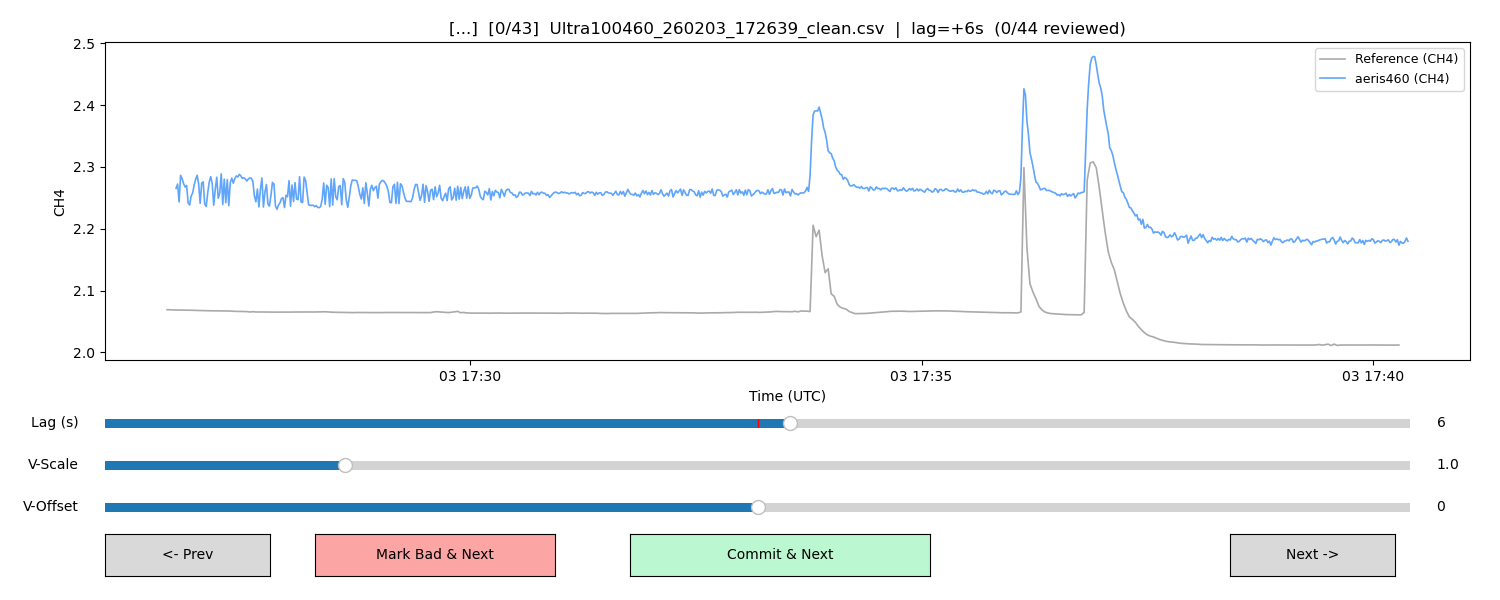

Commit & Next = good file | Mark Bad & Next = exclude file | Next = skip for now


In [14]:
if 'confirmed' not in dir():
    confirmed = {}
if 'rejected' not in dir():
    rejected = set()

state = {'idx': 0, 'ref_win': None, 'test_win': None}

plt.close('all')
fig = plt.figure(figsize=(15, 6))
ax  = fig.add_axes([0.07, 0.40, 0.91, 0.53])

# Sliders
ax_lag   = fig.add_axes([0.07, 0.28, 0.87, 0.03])
ax_scale = fig.add_axes([0.07, 0.21, 0.87, 0.03])
ax_voff  = fig.add_axes([0.07, 0.14, 0.87, 0.03])

s_lag   = mwidgets.Slider(ax_lag,   'Lag (s)',    -MAX_LAG_S, MAX_LAG_S, valinit=0,   valstep=1)
s_scale = mwidgets.Slider(ax_scale, 'V-Scale',    0.1,        5.0,       valinit=1.0)
s_voff  = mwidgets.Slider(ax_voff,  'V-Offset',   -500,       500,       valinit=0.0)

# Buttons
ax_prev   = fig.add_axes([0.07, 0.04, 0.11, 0.07])
ax_bad    = fig.add_axes([0.21, 0.04, 0.16, 0.07])
ax_commit = fig.add_axes([0.42, 0.04, 0.20, 0.07])
ax_next   = fig.add_axes([0.82, 0.04, 0.11, 0.07])

btn_prev   = mwidgets.Button(ax_prev,   '<- Prev',         color='0.85')
btn_bad    = mwidgets.Button(ax_bad,    'Mark Bad & Next', color='#fca5a5')
btn_commit = mwidgets.Button(ax_commit, 'Commit & Next',   color='#bbf7d0')
btn_next   = mwidgets.Button(ax_next,   'Next ->',         color='0.85')

line_ref  = [None]
line_test = [None]

def _status(key):
    if key in rejected:
        return 'BAD'
    if key in confirmed:
        return 'OK'
    return '...'

def _title():
    f     = test_files[state['idx']]
    key   = json_key(f)
    lag   = s_lag.val
    total = len(test_files)
    done  = len(confirmed) + len(rejected)
    return (f"[{_status(key)}]  [{state['idx']}/{total-1}]  {f.name}"
            f"  |  lag={lag:+.0f}s  ({done}/{total} reviewed)")

def load_and_draw(idx):
    f   = test_files[idx]
    key = json_key(f)
    lag = confirmed.get(key, suggestions.get(key, 0.0))

    test_rs = resample_series(load_cleaned(f, TEST_COL), RESAMPLE_S)
    t_start = max(ref_data.index[0], test_rs.index[0])
    t_end   = min(ref_data.index[-1], test_rs.index[-1])
    state['ref_win']  = ref_data[t_start:t_end]
    state['test_win'] = test_rs[t_start:t_end]

    test_color = '#f87171' if key in rejected else '#60a5fa'

    ax.cla()
    line_ref[0], = ax.plot(state['ref_win'].index, state['ref_win'].values,
                           color='#aaaaaa', lw=1.2, label=f'Reference ({REF_COL})')
    shifted = state['test_win'].index + pd.to_timedelta(lag, unit='s')
    line_test[0], = ax.plot(shifted, state['test_win'].values,
                            color=test_color, lw=1.2, label=f'{TEST_NAME} ({TEST_COL})')
    ax.set_xlabel('Time (UTC)')
    ax.set_ylabel(TEST_COL)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_title(_title())
    fig.autofmt_xdate()

    s_lag.set_val(lag)
    s_scale.set_val(1.0)
    s_voff.set_val(0.0)
    fig.canvas.draw_idle()

def update(_):
    if state['test_win'] is None:
        return
    shifted = state['test_win'].index + pd.to_timedelta(s_lag.val, unit='s')
    line_test[0].set_xdata(shifted)
    line_test[0].set_ydata(state['test_win'].values * s_scale.val + s_voff.val)
    ax.relim()
    ax.autoscale_view()
    ax.set_title(_title())
    fig.canvas.draw_idle()

s_lag.on_changed(update)
s_scale.on_changed(update)
s_voff.on_changed(update)

def _advance():
    if state['idx'] < len(test_files) - 1:
        state['idx'] += 1
        load_and_draw(state['idx'])
    else:
        print('  All files reviewed! Run the Save cell below.')

def on_prev(_):
    state['idx'] = max(0, state['idx'] - 1)
    load_and_draw(state['idx'])

def on_next(_):
    state['idx'] = min(len(test_files) - 1, state['idx'] + 1)
    load_and_draw(state['idx'])

def on_commit_next(_):
    f   = test_files[state['idx']]
    key = json_key(f)
    lag = float(s_lag.val)
    confirmed[key] = lag
    rejected.discard(key)
    print(f'  [OK]  [{state["idx"]}] {key}  ->  {lag:+.0f}s')
    _advance()

def on_bad(_):
    f   = test_files[state['idx']]
    key = json_key(f)
    rejected.add(key)
    confirmed.pop(key, None)
    print(f'  [BAD] [{state["idx"]}] {key}')
    _advance()

btn_prev.on_clicked(on_prev)
btn_next.on_clicked(on_next)
btn_commit.on_clicked(on_commit_next)
btn_bad.on_clicked(on_bad)

load_and_draw(0)
plt.show()
print('Commit & Next = good file | Mark Bad & Next = exclude file | Next = skip for now')

## Step 4 - Save to JSON
Merges all confirmed offsets into the JSON file. Safe to run multiple times.

In [15]:
offset_json   = OUTPUT_DIR / f'{OUTPUT_STEM}_timeshift.json'
rejected_path = OUTPUT_DIR / f'{OUTPUT_STEM}_rejected.json'

# Save confirmed offsets (merges with any previously saved values)
clean_confirmed = {k: v for k, v in confirmed.items() if k not in rejected}
existing = load_json(offset_json)
existing = {k: v for k, v in existing.items() if k not in rejected}
existing.update(clean_confirmed)
save_json(existing, offset_json)

# Save rejected list
save_json(sorted(rejected), rejected_path)

print(f'\n  Confirmed offsets : {len(clean_confirmed)}')
print(f'  Rejected (bad)    : {len(rejected)}')
print(f'\nOffsets:')
for k, v in existing.items():
    marker = '  <- updated' if k in clean_confirmed else ''
    print(f'  {k:<55} {v:+.0f}s{marker}')
if rejected:
    print(f'\nRejected:')
    for k in sorted(rejected):
        print(f'  {k}')

  Saved -> ../temp/data/aaron/aeris460_timeshift.json
  Saved -> ../temp/data/aaron/aeris460_rejected.json

  Confirmed offsets : 26
  Rejected (bad)    : 18

Offsets:
  Ultra100460_260203_172639.csv                           +6s  <- updated
  Ultra100460_260203_174018.csv                           +2s  <- updated
  Ultra100460_260203_195917.csv                           +4s  <- updated
  Ultra100460_260204_160118.csv                           +6s  <- updated
  Ultra100460_260204_163521.csv                           +6s  <- updated
  Ultra100460_260205_182229.csv                           +4s  <- updated
  Ultra100460_260206_175755.csv                           +0s  <- updated
  Ultra100460_260206_181207.csv                           +1s  <- updated
  Ultra100460_260206_203052.csv                           +1s  <- updated
  Ultra100460_260207_013301.csv                           +3s  <- updated
  Ultra100460_260208_013304.csv                           +4s  <- updated
  Ultra100460_2602